**In this Notebook we will do the following:**

- Construct the Pauli-Transfer-Matrix (PTM) of multiple Circuits
    - Memory Round: Surface Code
    - Lattice Surgery

- Invert the PTM to get an estimate of the Logical Operator

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [3]:
from src.core.data_models import NoiseParameters
from src.tools.qem_estimator.logical_level.calc_ptm import PTMCalculator
from src.core.data_models import PTMCircuits
from src.codes.lattice_surgery.builder import SurgeryBuilder
from itertools import product
from tqdm import tqdm
import gc

import stim

**PTM Calculation: Lattice Surgery**

In [4]:
#########################
# Construct Noise Class #
#########################
noise = 0.0

noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

############
# Circuits #
############

# Pauli alphabet for input and output states
PAULIS = ["I", "X", "Y", "Z"]

# Create Mapping for input states
input_to_init_state = {
    "X": ["X+", "X-"],
    "Y": ["Y+", "Y-"],
    "Z": ["Z0", "Z1"],
    "I": ["I0", "I1"],
}

circuits_surgery: dict[str, tuple[dict[str, stim.Circuit], list[int]]] = {}

# We combine the products so the progress bar tracks all 256 combinations
total_combinations = list(product(PAULIS, PAULIS, PAULIS, PAULIS))

for p_out_c, p_out_t, p_in_c, p_in_t in tqdm(total_combinations, desc="Generating Circuits"):

    # Initialize current measurement records and Circuit list
    curr_meas_rec: list[int] = []
    all_circuits: list[stim.Circuit] = []

    # Creating Label
    label_basis = f"{p_in_c}{p_in_t}->{p_out_c}{p_out_t}"

    # As the II->II flow has no observable, no flip prediction
    # by the decoder can be made!
    if label_basis == "II->II":
        continue

    # Creating inner dict
    inner_dict: dict[str, stim.Circuit] = {}

    # Inner loop for the 4 initial states
    for init_state_c, init_state_t in product(input_to_init_state[p_in_c], input_to_init_state[p_in_t]):
        # Creating state Label
        state_label = f"{init_state_c},{init_state_t}"

        builder = SurgeryBuilder(
            distance=3,
            control_state_init=init_state_c,
            target_state_init=init_state_t,
            control_measure_basis=p_out_c,
            target_measure_basis=p_out_t,
            noise=noise_class
        )

        circuit = builder.build_circuit()
        all_circuits.append(circuit)

        # It doesnt matter which records we get as the logical observable stays the same
        # in this loop
        curr_meas_rec = builder.get_logical_meas_rec(observable_index=0)

        # Adding the circuit to the inner dict
        inner_dict[state_label] = circuit

    # Adding to your existing dict
    circuits_surgery[label_basis] = (inner_dict, curr_meas_rec)

Generating Circuits:   0%|          | 0/256 [00:00<?, ?it/s]

Generating Circuits:  14%|█▍        | 37/256 [00:14<01:27,  2.50it/s]


KeyboardInterrupt: 

In [ ]:
import numpy as np

np.set_printoptions(precision=4, suppress=True, linewidth=200)

############################
# Calculate the PTM-Matrix #
############################

ptm_calculator = PTMCalculator(PTMCircuits(circuits=circuits_surgery), samples=1_000)
ptm_ideal = ptm_calculator.calc_ptm(only_non_zero=False)

# Clear Dict
circuits_surgery.clear()
gc.collect()

0

In [ ]:
#########################
# Construct Noise Class #
#########################
noise = 1e-4

noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

############
# Circuits #
############

# Pauli alphabet for input and output states
PAULIS = ["I", "X", "Y", "Z"]

# Create Mapping for input states
input_to_init_state = {
    "X": ["X+", "X-"],
    "Y": ["Y+", "Y-"],
    "Z": ["Z0", "Z1"],
    "I": ["I0", "I1"],
}

circuits_surgery: dict[str, tuple[dict[str, stim.Circuit], list[int]]] = {}

# We combine the products so the progress bar tracks all 256 combinations
total_combinations = list(product(PAULIS, PAULIS, PAULIS, PAULIS))

for p_out_c, p_out_t, p_in_c, p_in_t in tqdm(total_combinations, desc="Generating Circuits"):

    # Initialize current measurement records and Circuit list
    curr_meas_rec: list[int] = []
    all_circuits: list[stim.Circuit] = []

    # Creating Label
    label_basis = f"{p_in_c}{p_in_t}->{p_out_c}{p_out_t}"

    # As the II->II flow has no observable, no flip prediction
    # by the decoder can be made!
    if label_basis == "II->II":
        continue

    # Creating inner dict
    inner_dict: dict[str, stim.Circuit] = {}

    # Inner loop for the 4 initial states
    for init_state_c, init_state_t in product(input_to_init_state[p_in_c], input_to_init_state[p_in_t]):
        # Creating state Label
        state_label = f"{init_state_c},{init_state_t}"

        builder = SurgeryBuilder(
            distance=3,
            control_state_init=init_state_c,
            target_state_init=init_state_t,
            control_measure_basis=p_out_c,
            target_measure_basis=p_out_t,
            noise=noise_class
        )

        circuit = builder.build_circuit()
        all_circuits.append(circuit)

        # It doesnt matter which records we get as the logical observable stays the same
        # in this loop
        curr_meas_rec = builder.get_logical_meas_rec(observable_index=0)

        # Adding the circuit to the inner dict
        inner_dict[state_label] = circuit

    # Adding to your existing dict
    circuits_surgery[label_basis] = (inner_dict, curr_meas_rec)

Generating Circuits: 100%|██████████| 256/256 [04:39<00:00,  1.09s/it]


In [ ]:
############################
# Calculate the PTM-Matrix #
############################

ptm_calculator = PTMCalculator(PTMCircuits(circuits=circuits_surgery), samples=1_000)
ptm_noisy = ptm_calculator.calc_ptm(only_non_zero=False)

# Clear Dict
circuits_surgery.clear()
gc.collect()

0

**Logical-Estimator**

We now use the Noisy and the Ideal PTM in order to build the logical estimator

In [ ]:
from src.tools.qem_estimator.logical_level.logical_estimator_surgery import LogicalEstimatorSurgery

# Set II entry on both to one
ptm_ideal[0, 0] = 1
ptm_noisy[0, 0] = 1

# Building Class
cls = LogicalEstimatorSurgery(ptm_clean=ptm_ideal, ptm_noisy=ptm_noisy)

In [ ]:
# Get NoiseParamters
noise = 1e-4


noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

# Create Circuit which should be sampled
builder = SurgeryBuilder(
            distance=5,
            control_state_init="Z0",
            target_state_init="Y-",
            control_measure_basis="I",
            target_measure_basis="Y",
            noise=noise_class
)

circuit = builder.build_circuit()
measurement_records = builder.get_logical_meas_rec(observable_index=0)

# Sample Circuit
expectation_val = cls.sample_circuit(circuit, measurement_records, meas_basis="IY", shots=1_000)
print(f"Expectation Value: {expectation_val}")
cls.gamma

Expectation Value: -0.9985849890390817


np.float64(1.012763680567045)

**Overhead-Factor/ Physical Error Probability**

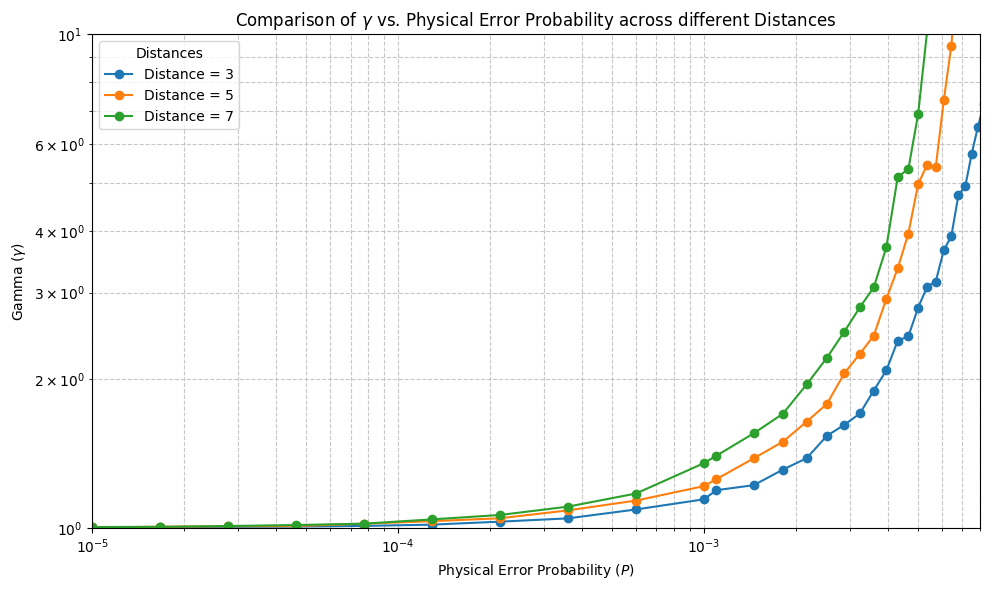

In [ ]:
# Load Results from file
import pandas as pd
results = pd.read_csv("gamma_standard.csv")

# Display the results
import matplotlib.pyplot as plt

# Sort the dataframe by probability to ensure the lines are drawn correctly
results_sorted = results.sort_values(by=['distance', 'physical_error_probability'])

# Create the plot
plt.figure(figsize=(10, 6))

# Group by 'distance' and plot each group separately
unique_distances = sorted(results_sorted['distance'].unique())

for dist in unique_distances:
    subset = results_sorted[results_sorted['distance'] == dist]
    plt.plot(subset['physical_error_probability'], subset['gamma'], marker='o', label=f'Distance = {dist}')

# Add labels using LaTeX formatting
plt.xlabel(r'Physical Error Probability ($P$)')
plt.ylabel(r'Gamma ($\gamma$)')
plt.title(r'Comparison of $\gamma$ vs. Physical Error Probability across different Distances')

# Add legend, grid, and layout formatting
plt.legend(title='Distances')
plt.grid(True, which= "both", linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.xlim(1e-5, 8e-3)
plt.ylim(1, 10)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()

# Save or show the plot
plt.savefig('gamma_plot.png', dpi=300)
plt.show()

In [4]:
import numpy as np

def walsh_hadamard_16() -> np.ndarray:
    """
    Return the 16x16 Walsh–Hadamard transform matrix H where:
        H[row, col] = (-1)^(i*j)
        -> i * j is the bitwise dot product of row and col
    """
    n = 16
    walsh_hadamard = np.empty((n, n), dtype=int)

    for row in range(n):
        for col in range(n):
            bitwdot = bin(row & col).count("1")
            walsh_hadamard[row, col] = (-1) ** bitwdot

    return walsh_hadamard

In [5]:
walsh_mtx = walsh_hadamard_16()

res = np.matmul(walsh_mtx, 1.0 / np.array([0.8, 0.6, 0.2, 0.4, 0.2, 0.2, 0.1, 0.9, 0.1, 0.2, 0.23, 0.23, 0.12, 0.84, 0.98, 0.01]))

nu = 1/16 * res

print(nu)
print(np.sum(abs(nu)))

[10.36047798 -4.74153203 -5.68041845  6.20730584 -6.09643812  5.6269487
  5.89554527 -5.94688917 -6.41950576  6.11305981  4.9686129  -7.68300028
  4.75963257 -6.47764314 -6.32957304  6.69341695]
100.0


In [14]:
import sinter
import os

In [15]:
import math

# geomspace replacement
geom = [10**(math.log10(1e-5) + i*(math.log10(1e-3) - math.log10(1e-5))/9) for i in range(10)]

# linspace replacement
lin = [1.1e-3 + i*(0.015 - 1.1e-3)/39 for i in range(40)]

p_values = geom + lin

In [16]:
noise = 1e-3

noise_class_circuit = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              before_round_depol=noise)

circuit= SurgeryBuilder(
            distance= 3,
            control_state_init= "X+",
            target_state_init= "I0",
            control_measure_basis= "X",
            target_measure_basis= "X",
            noise= noise_class_circuit
        ).build_circuit()

# Create a fresh NoiseParameters instance for the second builder
noise_class_circuit_2 = NoiseParameters(before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              before_round_depol=noise)

class_2 = SurgeryBuilder(distance=3, control_state_init="Y+", target_state_init="X+",
                                      control_measure_basis="Y", target_measure_basis="I", noise= noise_class_circuit_2)

circuit_2 = class_2.build_circuit()

In [18]:
import itertools
from tqdm import tqdm

distances = [3, 5, 7]

combinations = list(itertools.product(distances, p_values))

# 3. Build the tasks with a progress bar
tasks = [
    sinter.Task(
        circuit=SurgeryBuilder(
            distance=d,
            control_state_init="X+",
            target_state_init="I0",
            control_measure_basis="X",
            target_measure_basis="X",
            noise=NoiseParameters(
                before_round_depol=noise,
                before_m_flip_prob=noise,
                after_r_flip=noise,
                after_c_depol_prob=noise
            )
        ).build_circuit(),
        json_metadata={'d': d, 'p': noise},
    )
    for d, noise in tqdm(combinations, desc="Building Circuits")
]

# 4. Now hand them off to sinter
collected_stats = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=500,
    print_progress=True
)

Building Circuits: 100%|██████████| 150/150 [19:17<00:00,  7.72s/it]
Starting 8 workers...
150 tasks left:
  workers    decoder eta shots_left errors_left json_metadata               
        1 pymatching <1m      93583         500 d=3,p=1e-05                 
        1 pymatching   ?     100000         500 d=3,p=1.6681005372000593e-05
        1 pymatching   ?     100000         500 d=3,p=2.782559402207126e-05 
        1 pymatching   ?     100000         500 d=3,p=4.641588833612782e-05 
        1 pymatching   ?     100000         500 d=3,p=7.742636826811278e-05 
        1 pymatching   ?     100000         500 d=3,p=0.0001291549665014884 
        1 pymatching   ?     100000         500 d=3,p=0.00021544346900318823
        1 pymatching   ?     100000         500 d=3,p=0.00035938136638046257
        0 pymatching ?·∞     100000         500 d=3,p=0.0005994842503189409 
        0 pymatching ?·∞     100000         500 d=3,p=0.001                 
        0 pymatching ?·∞     100000         50

In [66]:
with open("surgery_threshold_standard.csv", "w") as f:
    # 1. Write the mandatory header
    print(sinter.CSV_HEADER, file=f)
    
    # 2. Write each task result as a CSV line
    for stat in collected_stats:
        print(stat.to_csv_line(), file=f)

In [67]:
from matplotlib import pyplot as plt

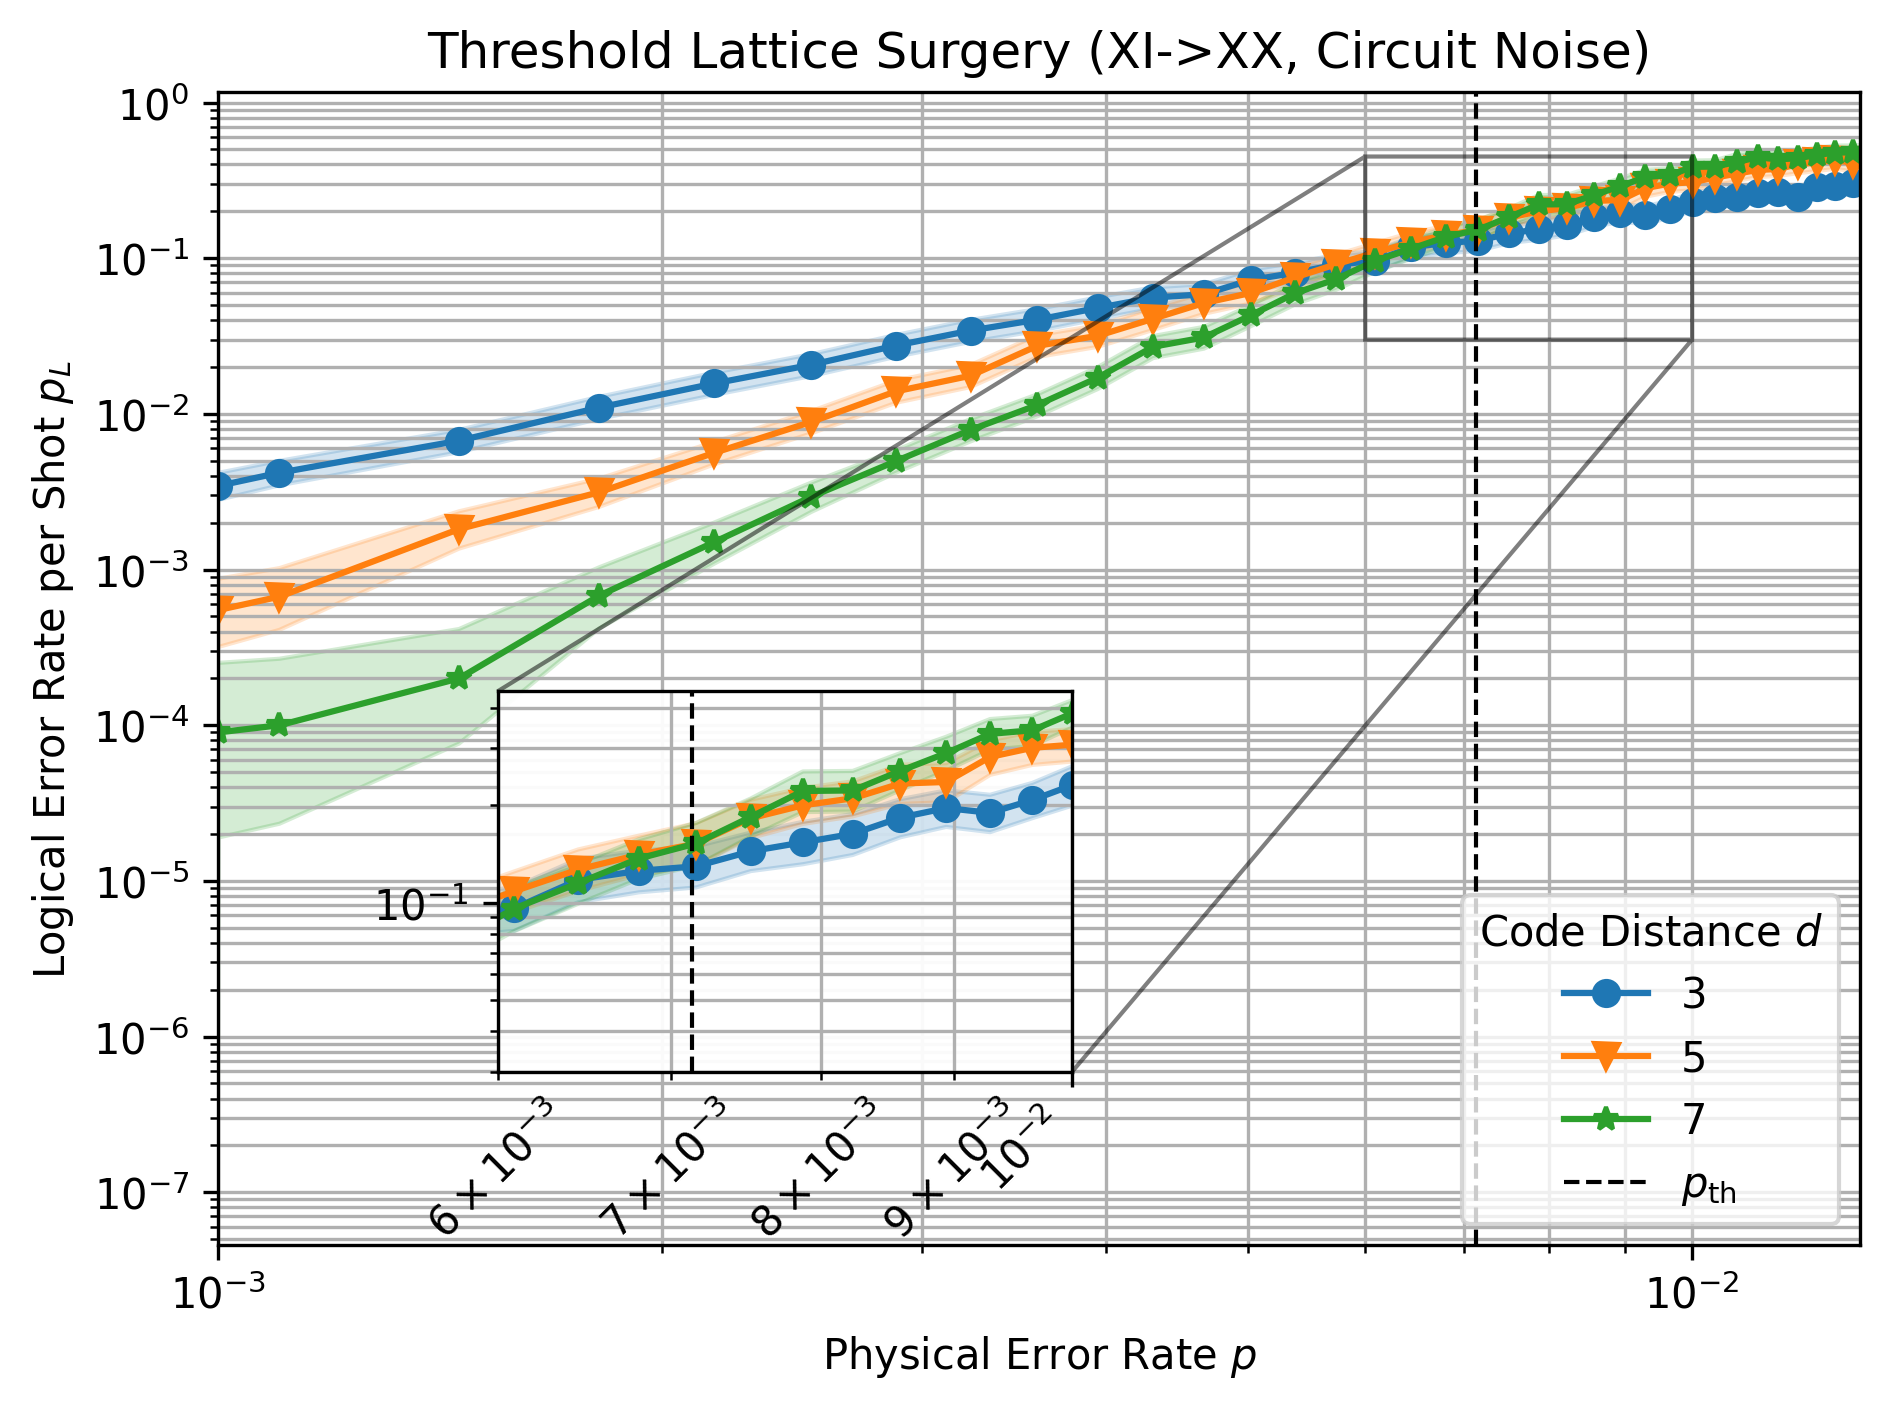

In [92]:
p_th = 0.713e-2

############################################
# Main Plot: Error Rates (Phenomenological)
############################################

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d']
)

# Threshold line
ax.axvline(
    x=p_th,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$p_{\mathrm{th}}$"
)

# Style main axes
ax.set_xlim(1e-3, 1.3e-2)
ax.loglog()
ax.set_title("Threshold Lattice Surgery (XI->XX, Circuit Noise)")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $p_L$")
ax.grid(which='major')
ax.grid(which='minor')

# Legend in the bottom right
ax.legend(title="Code Distance $d$", loc='lower right')

############################################
# Plotting Zoomed in Section (Bottom Left)
############################################

# [x0, y0, width, height]
# x0=0.15 shifts it right to avoid main y-axis labels
# y0=0.12 shifts it up to avoid main x-axis labels
axins = ax.inset_axes([0.17, 0.15, 0.35, 0.33])

sinter.plot_error_rate(
    ax=axins,
    stats=collected_stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: s.json_metadata['d'])

# Threshold line in zoom
axins.axvline(x=p_th, color="black", linestyle="--", linewidth=1)

# Zoom window limits
x1, x2, y1, y2 = 0.6e-2, 1.0e-2, 3e-2, 4.5e-1 
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.loglog()

# Style the inset
axins.grid(which='major')
axins.grid(which='minor')
axins.patch.set_facecolor("white")
axins.patch.set_alpha(0.95)

# Add the indicator boxes/lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# Rotate X-labels for clarity in the small window
axins.tick_params(axis='x', which='both', rotation=45)
for lbl in axins.get_xticklabels():
    lbl.set_ha('right') 

# Final figure settings
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
# bbox_inches='tight' ensures that labels or the inset box aren't cut off
plt.savefig("lattice_surgery_threshold.pdf", bbox_inches='tight')

# Show the plot
plt.show()

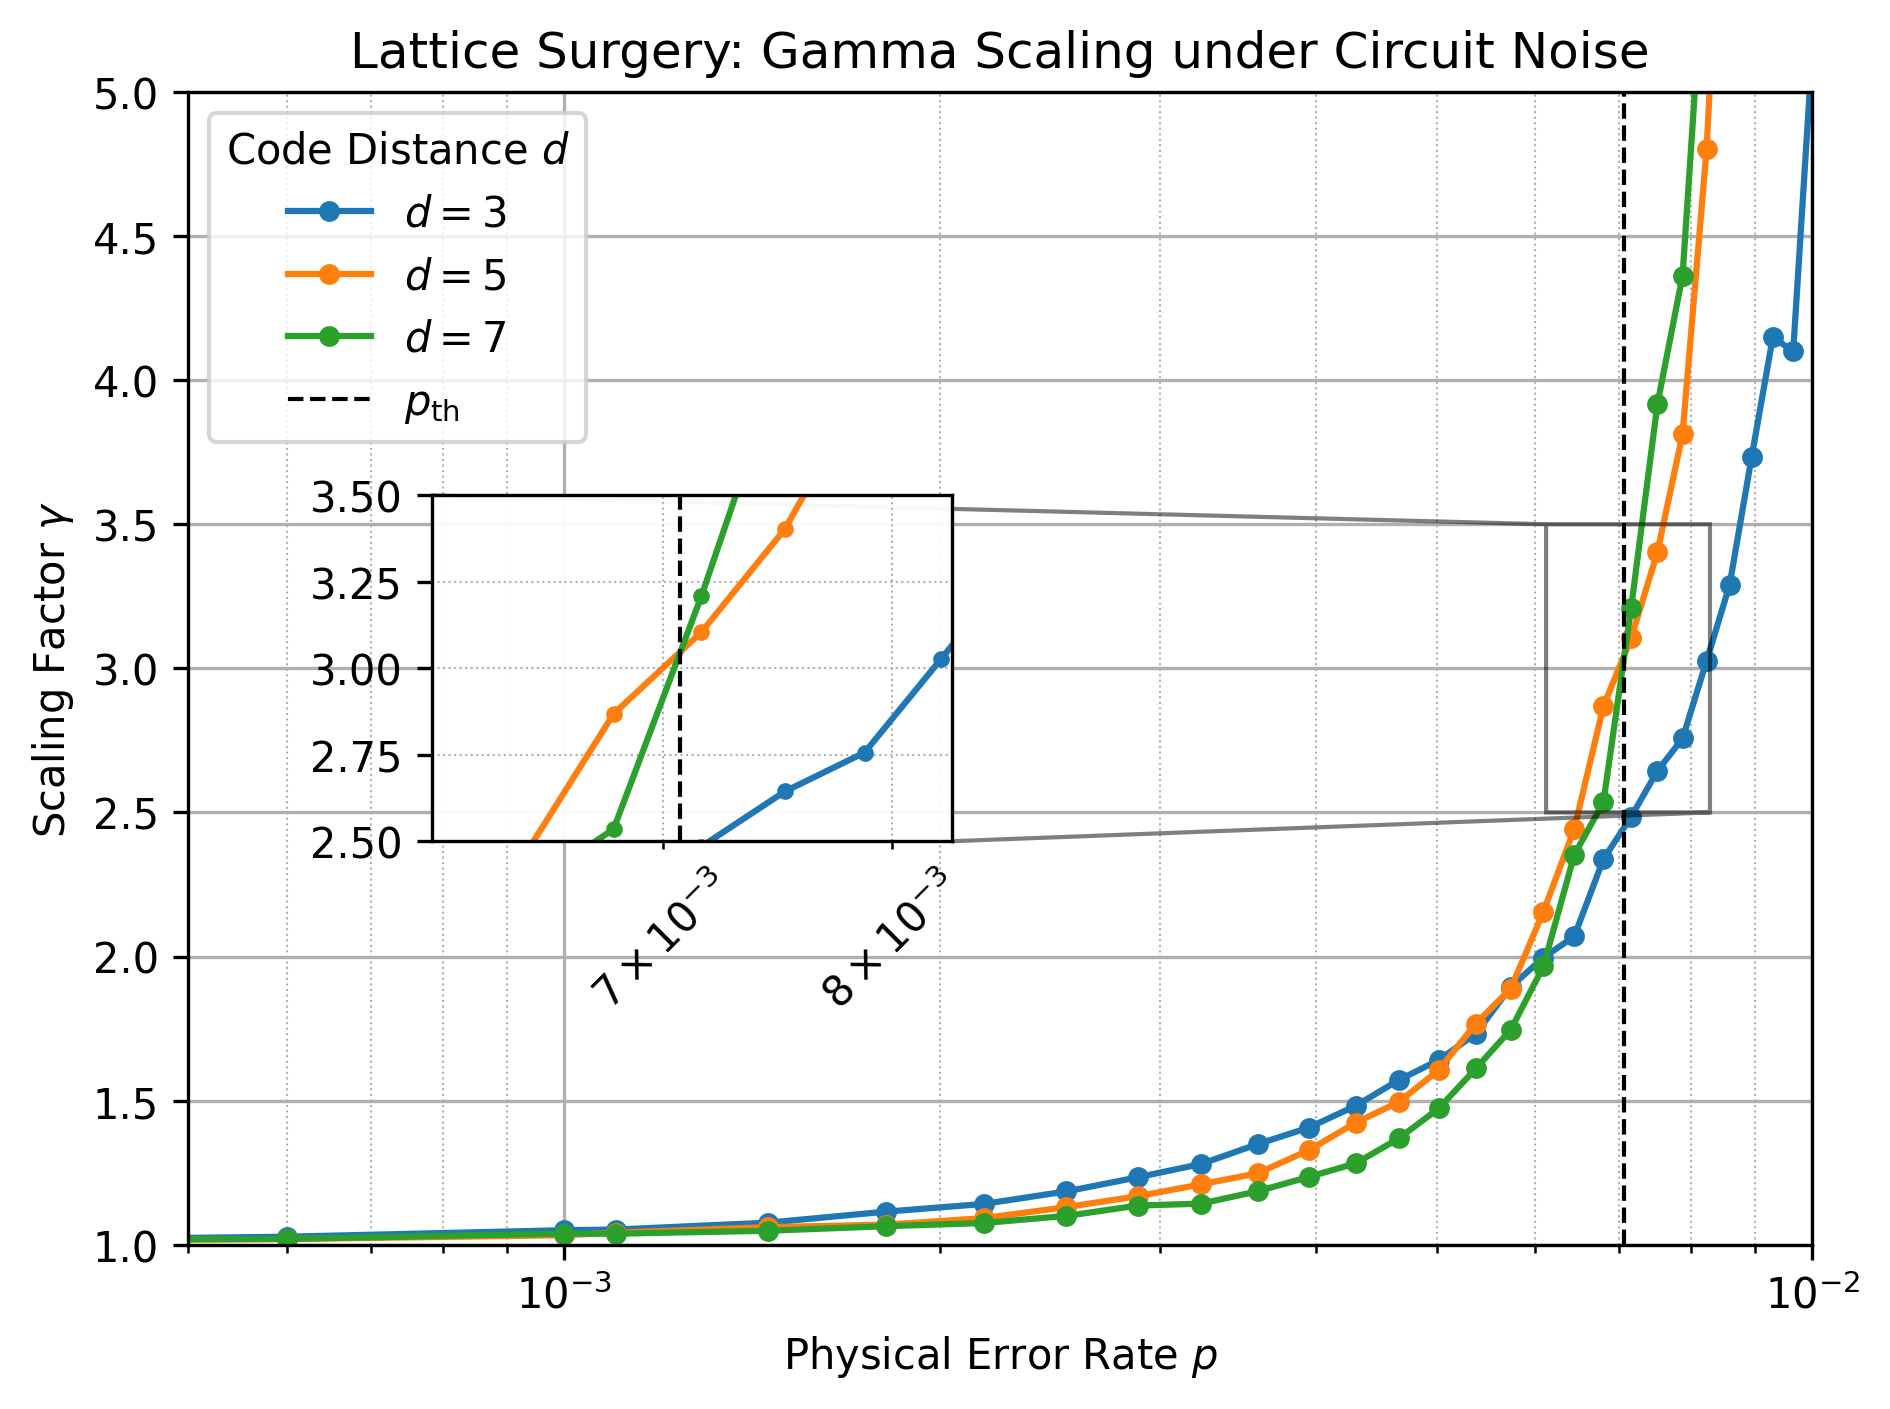

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('gamma_standard.csv')

p_th = 0.707e-2

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1)

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# Threshold line
ax.axvline(
    x=p_th,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$p_{\mathrm{th}}$"
)

# 3. Main Axis Formatting
ax.set_ylim(1.0, 5.0)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log') 
ax.set_title("Lattice Surgery: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8)
ax.grid(which='minor', linestyle=':', linewidth=0.5)

# Moved legend to upper right to avoid the inset box
ax.legend(title="Code Distance $d$", loc='upper left')

############################################
# 4. Inset Zoom (Middle-Left)
############################################

# Bounds: [x0, y0, width, height]
# x0=0.15: Shifts it slightly right of the y-axis labels
# y0=0.35: Places the bottom of the box near the vertical middle
axins = ax.inset_axes([0.15, 0.35, 0.32, 0.30])

for distance, group in df.groupby('distance'):
    axins.plot(group['physical_error_probability'], group['gamma'], marker='o', markersize=3)

# Center zoom around p = 0.008 and gamma = 3
# We define a window around these points
x_center = 0.72e-2
y_center = 3.0

x1, x2 = x_center * 0.85, x_center * 1.15  # Adjust multipliers to zoom in/out
y1, y2 = y_center - 0.5, y_center + 0.5

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Keep log scale if preferred, or remove for linear detail in the zoom
axins.set_xscale('log') 
axins.grid(which='both', linestyle=':', linewidth=0.5)
axins.patch.set_facecolor("white")
axins.patch.set_alpha(0.95)

# Threshold line in zoom
axins.axvline(x=p_th, color="black", linestyle="--", linewidth=1)

# Indicator lines
ax.indicate_inset_zoom(axins, edgecolor="black")

# Rotate labels for small box
axins.tick_params(axis='x', which='both', rotation=45)
for lbl in axins.get_xticklabels():
    lbl.set_ha('right') 

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("gamma_scaling.pdf", bbox_inches='tight')

plt.show()